In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

from xgboost import XGBClassifier

Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



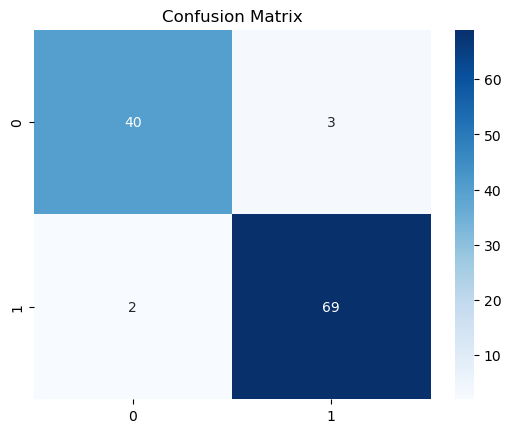

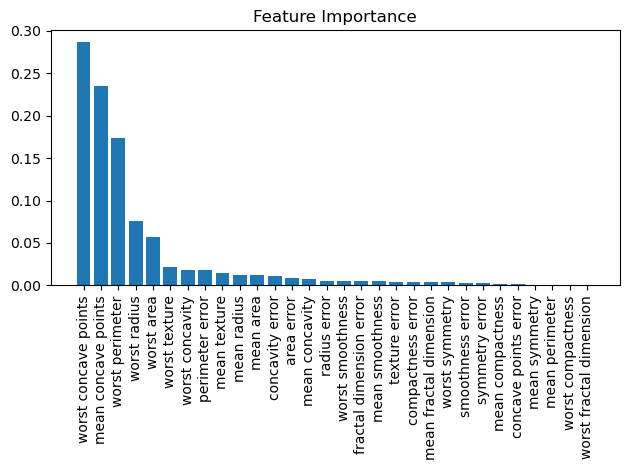

In [2]:
# 1. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Model
model = XGBClassifier(eval_metric='logloss')

# 4. Train
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True,cmap ="Blues")
plt.title("Confusion Matrix")

# 8. Feature Importance
plt.figure()
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), data.feature_names[indices], rotation=90)
plt.title("Feature Importance")
plt.tight_layout()

# Show all plots
plt.show()